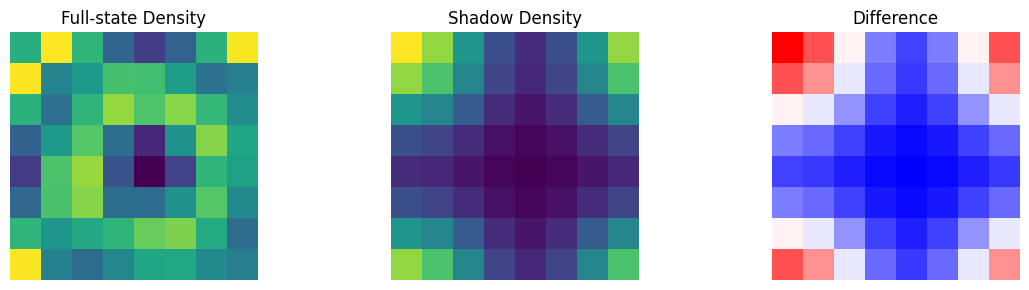

In [3]:
#%%
# =======================Generate state preparation quantum circuit===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import random
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Operator, Statevector, DensityMatrix
from numpy import pi, exp, sqrt, abs, real, imag
from scipy import linalg
from scipy.linalg import expm

# Shadow module utilities
from numpy.fft import fft2, ifft2, fftfreq


def kinetic_operator(n, dt):
    qc = QuantumCircuit(n)
    qc.rz(-2**(n-1)*dt, n-1)
    for i in range(n):
        qc.rz(2**(n-i-2)*dt, n-i-1)
    for i in range(1, n):
        qc.cx(n-1, n-i-1)
        qc.rz(-2**(2*n-i-2)*dt, n-i-1)
        qc.cx(n-1, n-i-1)
    for i in range(n):
        for j in range(n):
            if i != j:
                qc.cx(n-i-1, n-j-1)
                qc.rz(2**(2*n-i-j-4)*dt, n-j-1)
                qc.cx(n-i-1, n-j-1)
    return qc


def evolve(nx, ny, dt, initial_state):
    q_num = nx + ny + 1
    circ = QuantumCircuit(q_num)
    circ.initialize(initial_state)
    circ.barrier()

    from qiskit.circuit.library import QFT
    QFT_x = QFT(nx)
    QFT_y = QFT(ny)
    IQFT_x = QFT(nx).inverse()
    IQFT_y = QFT(ny).inverse()

    kinetic_x = kinetic_operator(nx, dt)
    kinetic_y = kinetic_operator(ny, dt)

    circ.append(QFT_x, range(nx))
    circ.append(QFT_y, range(nx, nx+ny))
    circ.barrier()

    circ.append(kinetic_x, range(nx))
    circ.append(kinetic_y, range(nx, nx+ny))
    circ.barrier()

    circ.append(IQFT_x, range(nx))
    circ.append(IQFT_y, range(nx, nx+ny))

    circ.save_state()
    simulator = AerSimulator(method='statevector')
    circ = transpile(circ, simulator)

    result = simulator.run(circ).result()
    tmp = np.array(result.data(0)['statevector'])
    return tmp


# =========================Output the wave function==========================
def compute_fluid_quantities(psi1, psi2):
    kx = fftfreq(N)*N
    ky = fftfreq(N)*N
    KX, KY = np.meshgrid(kx, ky)
    psi1_spec = fft2(psi1)
    dpsi1_x = ifft2(1j*KX*psi1_spec)
    dpsi1_y = ifft2(1j*KY*psi1_spec)
    psi2_spec = fft2(psi2)
    dpsi2_x = ifft2(1j*KX*psi2_spec)
    dpsi2_y = ifft2(1j*KY*psi2_spec)
    rho = np.abs(psi1)**2 + np.abs(psi2)**2
    ux = real(real(psi1)*imag(dpsi1_x) - imag(psi1)*real(dpsi1_x) + real(psi2)*imag(dpsi2_x) - imag(psi2)*real(dpsi2_x)) / rho
    uy = real(real(psi1)*imag(dpsi1_y) - imag(psi1)*real(dpsi1_y) + real(psi2)*imag(dpsi2_y) - imag(psi2)*real(dpsi2_y)) / rho
    vor = real(ifft2(1j*KX*fft2(uy) - 1j*KY*fft2(ux)))
    return ux, uy, vor, rho


# =========================Initial condition==========================
N = 2**3  # Reduced grid for shadow demo
x = np.linspace(-pi, pi, N, endpoint=False)
y = np.linspace(-pi, pi, N, endpoint=False)
dx = 2*pi/N
dy = 2*pi/N
X, Y = np.meshgrid(x, y)
x0 = 0
y0 = 0
R = sqrt((X - x0)**2 + (Y - y0)**2)
sigma = 3
f = exp(-(R/sigma)**4)
u = 2*(X + 1j*Y)*f / (1 + R**2)
v = 1j*(R**2 + 1 - 2*f) / (1 + R**2)
psi1_0 = u / sqrt(abs(u)**2 + abs(v)**4)
psi2_0 = v**2 / sqrt(abs(u)**2 + abs(v)**4)

initial_state = np.array([psi1_0, psi2_0]).reshape(-1)
initial_state /= np.linalg.norm(initial_state)


# =========================Run full-state evolution==========================
nx = int(np.log2(N))
dt = 1
tmp = evolve(nx, nx, dt, initial_state)
tmp = tmp.reshape(2, N, N)
psi1 = tmp[0, :, :]
psi2 = tmp[1, :, :]
ux, uy, vor, rho_full = compute_fluid_quantities(psi1, psi2)


# =========================Shadow Hamiltonian Evolution========================
M = N * N  # total Fourier modes

# Initial density in spectral space
psi1_spec = fft2(psi1_0)
psi2_spec = fft2(psi2_0)
rho_k0 = abs(psi1_spec)**2 + abs(psi2_spec)**2
shadow0 = rho_k0.flatten()

# Construct realistic spectral Hamiltonian (quadratic kinetic energy)
kx = fftfreq(N) * N
ky = fftfreq(N) * N
KX, KY = np.meshgrid(kx, ky)
k_squared = KX**2 + KY**2
H_spec_diag = k_squared.flatten()
H_spec = np.diag(H_spec_diag)

# Construct H_S matrix from commutator expectation rule
HS = np.zeros((M, M), dtype=complex)
for i in range(M):
    for j in range(M):
        Ei = np.zeros((M, M)); Ei[i, i] = 1.0
        Ej = np.zeros((M, M)); Ej[j, j] = 1.0
        comm = H_spec @ Ej - Ej @ H_spec
        HS[i, j] = -1j * np.trace(Ei @ comm)

# Shadow evolution
shadow_t = expm(-1j * HS * dt) @ shadow0
rho_shadow_k = shadow_t.reshape(N, N)
rho_shadow_x = real(ifft2(rho_shadow_k))


# =========================Compare density: full vs shadow========================
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
axs[0].imshow(rho_full, cmap='viridis'); axs[0].set_title("Full-state Density")
axs[1].imshow(rho_shadow_x, cmap='viridis'); axs[1].set_title("Shadow Density")
axs[2].imshow(rho_shadow_x - rho_full, cmap='bwr'); axs[2].set_title("Difference")
for ax in axs: ax.axis("off")
plt.tight_layout(); plt.show()
